<a href="https://colab.research.google.com/github/IremOzbek/CBIS-DDSM_dataset/blob/main/cbis_ddsm_balanced_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle opencv-python-headless Pillow tqdm matplotlib seaborn scikit-learn
print("✅ Kütüphaneler hazır.")

✅ Kütüphaneler hazır.


In [3]:
import os, shutil, json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("✅ İmport tamamlandı.")

✅ İmport tamamlandı.


In [4]:
from google.colab import files

# kaggle.com > Settings > API > "Create New Token" ile kaggle.json indir
print("📂 kaggle.json dosyanızı yükleyin:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_key = list(uploaded.values())[0]
if isinstance(kaggle_key, bytes):
    kaggle_key = kaggle_key.decode()
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_key)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle kimlik doğrulama tamamlandı.")

📂 kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json
✅ Kaggle kimlik doğrulama tamamlandı.


In [5]:
# ─── Veri Setini İndir ────────────────────────────────────────────────────────
# NOT: ~10 GB — 10-20 dakika sürebilir (Colab ağ hızına bağlı)

DATASET_SLUG = 'awsaf49/cbis-ddsm-breast-cancer-image-dataset'
DOWNLOAD_DIR = '/content/cbis_raw'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("⬇️  İndiriliyor... (bu işlem 10-20 dakika sürebilir)")
!kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_DIR} --unzip
print("\n✅ İndirme tamamlandı!")

⬇️  İndiriliyor... (bu işlem 10-20 dakika sürebilir)
Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:55<00:00, 96.3MB/s]


✅ İndirme tamamlandı!


In [6]:
# Klasör yapısını keşfet
print("📁 Veri seti klasör yapısı:")
for root, dirs, flist in os.walk(DOWNLOAD_DIR):
    level = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    if level <= 1:
        for fname in flist[:4]:
            print(f"{indent}  📄 {fname}")
        if len(flist) > 4:
            print(f"{indent}  ... (+{len(flist)-4} dosya)")

📁 Veri seti klasör yapısı:
📂 cbis_raw/
  📂 csv/
    📄 dicom_info.csv
    📄 meta.csv
    📄 mass_case_description_test_set.csv
    📄 calc_case_description_train_set.csv
    ... (+2 dosya)
  📂 jpeg/
    📂 1.3.6.1.4.1.9590.100.1.2.11223356112180875716745240381398643422/
    📂 1.3.6.1.4.1.9590.100.1.2.364350115212430791205570300382328406712/
    📂 1.3.6.1.4.1.9590.100.1.2.74027474310821018314806355672297628810/
    📂 1.3.6.1.4.1.9590.100.1.2.215811327512259684015646982651405467155/
    📂 1.3.6.1.4.1.9590.100.1.2.51457123011337046939870076193775211718/
    📂 1.3.6.1.4.1.9590.100.1.2.126931471711950064228802134232479763588/
    📂 1.3.6.1.4.1.9590.100.1.2.376080985712438416829430109780759130743/
    📂 1.3.6.1.4.1.9590.100.1.2.69102481911614345738992761764104656383/
    📂 1.3.6.1.4.1.9590.100.1.2.32463216011457113835513033213000093917/
    📂 1.3.6.1.4.1.9590.100.1.2.244985281912684166022125638963297133648/
    📂 1.3.6.1.4.1.9590.100.1.2.364769939511865969122167341301370556814/
    📂 1.3.6.1.4.1

In [7]:
# ─── CSV Yolları ──────────────────────────────────────────────────────────────
CSV_DIR  = os.path.join(DOWNLOAD_DIR, 'csv')
JPEG_DIR = os.path.join(DOWNLOAD_DIR, 'jpeg')

# Tüm CSV'leri listele
print("📄 Bulunan CSV dosyaları:")
for f in sorted(Path(CSV_DIR).glob('*.csv')):
    df_tmp = pd.read_csv(f, nrows=1)
    print(f"  {f.name:55s}  →  {len(pd.read_csv(f))} satır, {len(df_tmp.columns)} sütun")

📄 Bulunan CSV dosyaları:
  calc_case_description_test_set.csv                       →  326 satır, 14 sütun
  calc_case_description_train_set.csv                      →  1546 satır, 14 sütun
  dicom_info.csv                                           →  10237 satır, 38 sütun
  mass_case_description_test_set.csv                       →  378 satır, 14 sütun
  mass_case_description_train_set.csv                      →  1318 satır, 14 sütun
  meta.csv                                                 →  6775 satır, 9 sütun


In [24]:
# ─── Case Description CSV'leri ────────────────────────────────────────────────
mass_train_csv = pd.read_csv(os.path.join(CSV_DIR, 'mass_case_description_train_set.csv'))
mass_test_csv  = pd.read_csv(os.path.join(CSV_DIR, 'mass_case_description_test_set.csv'))
calc_train_csv = pd.read_csv(os.path.join(CSV_DIR, 'calc_case_description_train_set.csv'))
calc_test_csv  = pd.read_csv(os.path.join(CSV_DIR, 'calc_case_description_test_set.csv'))

# ─── DICOM Meta CSV ───────────────────────────────────────────────────────────
dicom_df = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))

print("=== MASS TRAIN sütunları ===")
print(mass_train_csv.columns.tolist())
print()
print("=== MASS TRAIN ilk satır (pathology) ===")
print(mass_train_csv['pathology'].value_counts())
print()
print("=== CALC TRAIN ilk satır (pathology) ===")
print(calc_train_csv['pathology'].value_counts())
print()
print("=== DICOM SeriesDescription ===")
print(dicom_df['SeriesDescription'].value_counts(dropna=False))
print()
print("=== DICOM image_path örneği ===")
print(dicom_df['image_path'].dropna().iloc[0])

=== MASS TRAIN sütunları ===
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

=== MASS TRAIN ilk satır (pathology) ===
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

=== CALC TRAIN ilk satır (pathology) ===
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

=== DICOM SeriesDescription ===
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
NaN                       566
Name: count, dtype: int64

=== DICOM image_path örneği ===
CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg


In [9]:
import os
from pathlib import Path

# JPEG klasörünü bul
DOWNLOAD_DIR = '/content/cbis_raw'

# Olası jpeg klasör yolları
candidates = [
    os.path.join(DOWNLOAD_DIR, 'jpeg'),
    os.path.join(DOWNLOAD_DIR, 'CBIS-DDSM', 'jpeg'),
    os.path.join(DOWNLOAD_DIR, 'cbis-ddsm-breast-cancer-image-dataset', 'jpeg'),
]

JPEG_DIR = None
for c in candidates:
    if os.path.exists(c):
        JPEG_DIR = c
        break

if JPEG_DIR is None:
    # Derinlemesine ara
    for root, dirs, files in os.walk(DOWNLOAD_DIR):
        for d in dirs:
            if d.lower() == 'jpeg':
                JPEG_DIR = os.path.join(root, d)
                break
        if JPEG_DIR:
            break

print(f"JPEG_DIR : {JPEG_DIR}")

# Alt klasör sayısı ve örnek dosya
if JPEG_DIR:
    subdirs = list(Path(JPEG_DIR).iterdir())
    print(f"Alt klasör sayısı: {len(subdirs)}")
    print(f"Örnek alt klasör : {subdirs[0] if subdirs else 'YOK'}")

    # İlk jpg dosyasını bul
    first_jpg = next(Path(JPEG_DIR).rglob('*.jpg'), None)
    print(f"İlk JPG dosyası  : {first_jpg}")
else:
    print("❌ JPEG klasörü bulunamadı!")
    print("Mevcut klasörler:")
    for item in Path(DOWNLOAD_DIR).iterdir():
        print(f"  {item}")

JPEG_DIR : /content/cbis_raw/jpeg
Alt klasör sayısı: 6774
Örnek alt klasör : /content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.11223356112180875716745240381398643422
İlk JPG dosyası  : /content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.11223356112180875716745240381398643422/1-122.jpg


In [10]:
JPEG_DIR = '/content/cbis_raw/jpeg'
CSV_DIR  = '/content/cbis_raw/csv'

def kaggle_path_to_local(p):
    """
    'CBIS-DDSM/jpeg/UID/1-1.jpg'  →  '/content/cbis_raw/jpeg/UID/1-1.jpg'
    Dosya yoksa None döner.
    """
    if pd.isna(p):
        return None
    p = str(p).replace('\\', '/')
    marker = 'CBIS-DDSM/jpeg/'
    idx = p.find(marker)
    if idx >= 0:
        rel   = p[idx + len(marker):]
        local = os.path.join(JPEG_DIR, rel)
    else:
        local = os.path.join(JPEG_DIR, p.lstrip('/'))
    return local if os.path.exists(local) else None


def get_view(path):
    """Dosya yolundan MLO / CC çıkarır."""
    p = str(path).upper()
    if 'MLO' in p:
        return 'MLO'
    if '_CC' in p or '/CC' in p or 'LEFT_CC' in p or 'RIGHT_CC' in p:
        return 'CC'
    return 'UNKNOWN'


# ── Test ──────────────────────────────────────────────────────────────────────
sample = dicom_df[dicom_df['SeriesDescription'] == 'full mammogram images']['image_path'].iloc[0]
local  = kaggle_path_to_local(sample)
print(f"Ham yol    : {sample}")
print(f"Yerel yol  : {local}")
print(f"Dosya var? : {os.path.exists(local) if local else False}")
print(f"View       : {get_view(local) if local else '-'}")

# Kaç tane full mammogram çözümleniyor?
full_mask  = dicom_df['SeriesDescription'] == 'full mammogram images'
full_dicom = dicom_df[full_mask].copy()
full_dicom['local_path'] = full_dicom['image_path'].apply(kaggle_path_to_local)
found = full_dicom['local_path'].notna().sum()
print(f"\nFull mammogram toplam   : {len(full_dicom)}")
print(f"Dosya bulunan           : {found}")
print(f"Bulunamayan             : {len(full_dicom) - found}")

Ham yol    : CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
Yerel yol  : /content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
Dosya var? : True
View       : UNKNOWN

Full mammogram toplam   : 2857
Dosya bulunan           : 2857
Bulunamayan             : 0


In [11]:
# dicom_info sütunlarını ve örnek değerleri incele
print("=== DICOM INFO sütunları ===")
print(dicom_df.columns.tolist())
print()

# Full mammogram satırlarında view ile ilgili sütunları ara
full_sample = dicom_df[dicom_df['SeriesDescription'] == 'full mammogram images'].head(10)

# image_path içindeki klasör adlarına bak
print("=== image_path örnekleri (full mammogram) ===")
for p in full_sample['image_path'].values:
    print(f"  {p}")

print()
# SeriesInstanceUID veya PatientID sütunlarına bak
view_cols = [c for c in dicom_df.columns if any(
    kw in c.lower() for kw in ['view','side','lateral','position','image']
)]
print(f"=== View ile ilgili olabilecek sütunlar ===")
print(view_cols)
print()
print("=== Bu sütunların örnek değerleri ===")
for col in view_cols:
    print(f"\n  [{col}]")
    print(f"  {dicom_df[col].value_counts(dropna=False).head(6).to_dict()}")

print()
# mass_train_csv'deki 'image view' sütununa bak
print("=== mass_train 'image view' değerleri ===")
print(mass_train_csv['image view'].value_counts())
print()
print("=== mass_train 'image file path' örneği ===")
print(mass_train_csv['image file path'].iloc[0])

=== DICOM INFO sütunları ===
['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']

=== image_path örnekleri (full mammogram) ===
  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213171011171858918434139331210917771/1-032.jpg
  CBIS-DDSM/jpeg/1.3.6.1.4.1.

In [12]:
# mass_train'deki 'image file path' formatını incele
print("=== mass_train 'image file path' ilk 5 satır ===")
for p in mass_train_csv['image file path'].head(5).values:
    print(f"  {p}")

print()
print("=== calc_train 'image file path' ilk 5 satır ===")
for p in calc_train_csv['image file path'].head(5).values:
    print(f"  {p}")

print()
# PatientID sütunu var mı, formatı ne?
print("=== mass_train patient_id örnekleri ===")
print(mass_train_csv['patient_id'].head(10).tolist())

print()
print("=== mass_train 'image view' + 'image file path' ilk 5 ===")
print(mass_train_csv[['patient_id','image view','left or right breast','image file path']].head(5).to_string())

print()
# dicom_info PatientID formatı
print("=== dicom_info PatientID örnekleri ===")
print(dicom_df['PatientID'].head(10).tolist())

print()
# dicom_info'da full mammogram için PatientID + image_path
full_dicom_sample = dicom_df[dicom_df['SeriesDescription']=='full mammogram images'][['PatientID','image_path']].head(5)
print("=== dicom full mammogram PatientID + image_path ===")
print(full_dicom_sample.to_string())

=== mass_train 'image file path' ilk 5 satır ===
  Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
  Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm
  Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/000000.dcm
  Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.272600286511817402806912403581910920939/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/000000.dcm
  Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.174047308712169195014610267031196524486/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/000000.dcm

=== calc_train 'image file path' ilk 5 satır ===
  Calc-Training_P_00005_RIGHT_CC/

In [13]:
from sklearn.model_selection import train_test_split
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Yardımcı: case CSV'deki dcm yolunu → local jpeg yoluna çevir ──────────────
# Strateji: case CSV'deki folder adı (Mass-Training_P_00001_LEFT_CC) +
#           dicom_info'daki PatientID eşleşmesi → jpeg yolu

# Önce dicom_info'dan full mammogram için PatientID → local_path haritası kur
full_dicom = dicom_df[dicom_df['SeriesDescription'] == 'full mammogram images'].copy()
full_dicom['local_path'] = full_dicom['image_path'].apply(kaggle_path_to_local)
full_dicom = full_dicom.dropna(subset=['local_path'])

# PatientID'den view çıkar
def view_from_patientid(pid):
    pid = str(pid).upper()
    if '_MLO' in pid:
        return 'MLO'
    if '_CC' in pid:
        return 'CC'
    return 'UNKNOWN'

full_dicom['view'] = full_dicom['PatientID'].apply(view_from_patientid)

# PatientID'den hasta numarası çıkar (P_00001 gibi)
import re
def extract_pnum(pid):
    m = re.search(r'P_\d+', str(pid))
    return m.group(0) if m else str(pid)

full_dicom['pnum'] = full_dicom['PatientID'].apply(extract_pnum)

print("Full mammogram view dağılımı:")
print(full_dicom['view'].value_counts())
print(f"\nToplam full mammogram: {len(full_dicom)}")
print(f"Örnek PatientID: {full_dicom['PatientID'].iloc[0]}")
print(f"Örnek pnum:      {full_dicom['pnum'].iloc[0]}")
print(f"Örnek view:      {full_dicom['view'].iloc[0]}")
print(f"Örnek local_path: {full_dicom['local_path'].iloc[0]}")

Full mammogram view dağılımı:
view
MLO    1511
CC     1346
Name: count, dtype: int64

Toplam full mammogram: 2857
Örnek PatientID: Mass-Training_P_01754_RIGHT_CC
Örnek pnum:      P_01754
Örnek view:      CC
Örnek local_path: /content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg


In [15]:
print("=== MASS TRAIN sütunları ===")
print(mass_train_csv.columns.tolist())
print()
print("=== CALC TRAIN sütunları ===")
print(calc_train_csv.columns.tolist())

=== MASS TRAIN sütunları ===
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

=== CALC TRAIN sütunları ===
['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


In [16]:
def get_col(row, *candidates):
    """Birden fazla olası sütun adını dener, bulduğunu döner."""
    for c in candidates:
        if c in row.index:
            return row[c]
    return np.nan

def build_records(case_df, abnormality_type):
    records = []

    for _, row in case_df.iterrows():
        img_file_path = str(row['image file path'])
        folder_name   = img_file_path.split('/')[0]

        # dicom_info'dan eşleştir
        match = full_dicom[
            full_dicom['PatientID'].str.upper() == folder_name.upper()
        ]
        if len(match) == 0:
            match = full_dicom[
                full_dicom['PatientID'].str.upper().str.startswith(folder_name.upper())
            ]
        if len(match) == 0:
            continue

        # Patoloji
        pathology = str(row['pathology']).strip().upper()
        if pathology in ('BENIGN', 'BENIGN_WITHOUT_CALLBACK'):
            label = 'BENIGN'
        elif pathology == 'MALIGNANT':
            label = 'MALIGNANT'
        else:
            continue

        for _, drow in match.iterrows():
            records.append({
                'patient_id'    : row['patient_id'],
                'image_path'    : drow['local_path'],
                'label'         : label,
                'view'          : drow['view'],
                'pathology_raw' : pathology,
                'abn_type'      : abnormality_type,
                'breast_side'   : str(row['left or right breast']).upper(),
                'image_view_csv': str(row['image view']).upper(),
                'assessment'    : row['assessment'],
                'breast_density': get_col(row, 'breast_density', 'breast density'),
                'subtlety'      : row['subtlety'],
            })

    return pd.DataFrame(records)


print("📦 Kayıtlar oluşturuluyor...")
df_mass_tr = build_records(mass_train_csv, 'mass')
print(f"  mass_train : {len(df_mass_tr)}")
df_mass_te = build_records(mass_test_csv,  'mass')
print(f"  mass_test  : {len(df_mass_te)}")
df_calc_tr = build_records(calc_train_csv, 'calc')
print(f"  calc_train : {len(df_calc_tr)}")
df_calc_te = build_records(calc_test_csv,  'calc')
print(f"  calc_test  : {len(df_calc_te)}")

abnormal_df = pd.concat([df_mass_tr, df_mass_te,
                         df_calc_tr, df_calc_te], ignore_index=True)

before = len(abnormal_df)
abnormal_df = abnormal_df.drop_duplicates(subset='image_path').reset_index(drop=True)

print(f"\nToplam (deduplicate öncesi) : {before}")
print(f"Toplam (deduplicate sonrası): {len(abnormal_df)}")
print(f"\n=== Etiket dağılımı ===")
print(abnormal_df['label'].value_counts())
print(f"\n=== View dağılımı ===")
print(abnormal_df['view'].value_counts())
print(f"\n=== Etiket x View ===")
print(abnormal_df.groupby(['label','view']).size().unstack(fill_value=0))

📦 Kayıtlar oluşturuluyor...
  mass_train : 1318
  mass_test  : 378
  calc_train : 1546
  calc_test  : 44

Toplam (deduplicate öncesi) : 3286
Toplam (deduplicate sonrası): 2857

=== Etiket dağılımı ===
label
BENIGN       1589
MALIGNANT    1268
Name: count, dtype: int64

=== View dağılımı ===
view
MLO    1511
CC     1346
Name: count, dtype: int64

=== Etiket x View ===
view        CC  MLO
label              
BENIGN     749  840
MALIGNANT  597  671


In [17]:
# Anormal görüntülerin yol kümesi
abnormal_paths = set(abnormal_df['image_path'].tolist())
print(f"Anormal görüntü kümesi : {len(abnormal_paths)}")

# full_dicom'dan anormalleri çıkar → NORMAL adaylar
normal_candidates = full_dicom[
    ~full_dicom['local_path'].isin(abnormal_paths)
].copy()

# Yalnızca MLO ve CC olanları al
normal_candidates = normal_candidates[
    normal_candidates['view'].isin(['MLO', 'CC'])
].reset_index(drop=True)

# PatientID'den hasta numarası çıkar
normal_candidates['patient_id'] = normal_candidates['PatientID'].apply(extract_pnum)

normal_df = pd.DataFrame({
    'patient_id'    : normal_candidates['patient_id'].values,
    'image_path'    : normal_candidates['local_path'].values,
    'label'         : 'NORMAL',
    'view'          : normal_candidates['view'].values,
    'pathology_raw' : 'NORMAL',
    'abn_type'      : 'normal',
    'breast_side'   : 'UNKNOWN',
    'image_view_csv': normal_candidates['view'].values,
    'assessment'    : np.nan,
    'breast_density': np.nan,
    'subtlety'      : np.nan,
})

print(f"Normal aday görüntü    : {len(normal_df)}")
print(f"\n=== Normal view dağılımı ===")
print(normal_df['view'].value_counts())

# Tüm veriyi birleştir
full_df = pd.concat([abnormal_df, normal_df], ignore_index=True)

print(f"\n=== HAM VERİ SETİ ÖZET ===")
print(f"Toplam görüntü: {len(full_df)}")
print(f"\nSınıf dağılımı:")
print(full_df['label'].value_counts())
print(f"\nSınıf x View:")
print(full_df.groupby(['label','view']).size().unstack(fill_value=0))

Anormal görüntü kümesi : 2857
Normal aday görüntü    : 0

=== Normal view dağılımı ===
Series([], Name: count, dtype: int64)

=== HAM VERİ SETİ ÖZET ===
Toplam görüntü: 2857

Sınıf dağılımı:
label
BENIGN       1589
MALIGNANT    1268
Name: count, dtype: int64

Sınıf x View:
view        CC  MLO
label              
BENIGN     749  840
MALIGNANT  597  671


In [18]:
from sklearn.model_selection import train_test_split
import os, shutil, json
from tqdm import tqdm
from pathlib import Path

RANDOM_SEED = 42
CLASSES     = ['BENIGN', 'MALIGNANT']
OUTPUT_DIR  = '/content/CBIS_2Class'

# ── Mevcut sayılar ────────────────────────────────────────────────────────────
n_benign    = abnormal_df['label'].eq('BENIGN').sum()
n_malignant = abnormal_df['label'].eq('MALIGNANT').sum()
print(f"BENIGN    : {n_benign}")
print(f"MALIGNANT : {n_malignant}")

# ── Undersampling: en küçük sınıfa göre dengele ───────────────────────────────
N = min(n_benign, n_malignant)
print(f"\nSınıf başına hedef : {N}")
print(f"Toplam             : {N * 2}")

benign_s    = abnormal_df[abnormal_df['label'] == 'BENIGN'   ].sample(N, random_state=RANDOM_SEED)
malignant_s = abnormal_df[abnormal_df['label'] == 'MALIGNANT'].sample(N, random_state=RANDOM_SEED)

balanced_df = pd.concat([benign_s, malignant_s], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"\n=== Dengeli veri seti ===")
print(balanced_df['label'].value_counts())
print(f"\n=== Sınıf x View ===")
print(balanced_df.groupby(['label','view']).size().unstack(fill_value=0))

BENIGN    : 1589
MALIGNANT : 1268

Sınıf başına hedef : 1268
Toplam             : 2536

=== Dengeli veri seti ===
label
MALIGNANT    1268
BENIGN       1268
Name: count, dtype: int64

=== Sınıf x View ===
view        CC  MLO
label              
BENIGN     603  665
MALIGNANT  597  671


In [19]:
import os
import shutil
from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42

# ─────────────────────────────────────────────
# 1) SADECE BENIGN / MALIGNANT AL
# ─────────────────────────────────────────────
df = abnormal_df[abnormal_df['label'].isin(['BENIGN', 'MALIGNANT'])].copy()

print("Orijinal dağılım:")
print(df['label'].value_counts())

# ─────────────────────────────────────────────
# 2) DENGELE (UNDERSAMPLING)
# ─────────────────────────────────────────────
min_count = df['label'].value_counts().min()

df_balanced = df.groupby('label').sample(n=min_count, random_state=RANDOM_SEED).reset_index(drop=True)

print("\nDengeli dağılım:")
print(df_balanced['label'].value_counts())

# ─────────────────────────────────────────────
# 3) PATIENT-LEVEL 80/20 SPLIT
# ─────────────────────────────────────────────
splitter = GroupShuffleSplit(test_size=0.2, random_state=RANDOM_SEED)

train_idx, test_idx = next(
    splitter.split(df_balanced, groups=df_balanced["patient_id"])
)

train_df = df_balanced.iloc[train_idx].reset_index(drop=True)
test_df  = df_balanced.iloc[test_idx].reset_index(drop=True)

print("\nTRAIN / TEST:")
print(len(train_df), len(test_df))

print("\nTRAIN LABEL:")
print(train_df['label'].value_counts())

print("\nTEST LABEL:")
print(test_df['label'].value_counts())

print("\nTRAIN VIEW:")
print(train_df['view'].value_counts())

print("\nTEST VIEW:")
print(test_df['view'].value_counts())

Orijinal dağılım:
label
BENIGN       1589
MALIGNANT    1268
Name: count, dtype: int64

Dengeli dağılım:
label
BENIGN       1268
MALIGNANT    1268
Name: count, dtype: int64

TRAIN / TEST:
2028 508

TRAIN LABEL:
label
BENIGN       1027
MALIGNANT    1001
Name: count, dtype: int64

TEST LABEL:
label
MALIGNANT    267
BENIGN       241
Name: count, dtype: int64

TRAIN VIEW:
view
MLO    1069
CC      959
Name: count, dtype: int64

TEST VIEW:
view
MLO    267
CC     241
Name: count, dtype: int64


In [26]:
import shutil
import os

dataset_path = "/content/CBIS_2CLASS_MLO_CC"

if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)
    print("Eski dataset silindi.")
else:
    print("Dataset bulunamadı.")

Eski dataset silindi.


In [27]:
OUTPUT_DIR = "/content/CBIS_2CLASS_MLO_CC"

train_dir = os.path.join(OUTPUT_DIR, "train")
test_dir  = os.path.join(OUTPUT_DIR, "test")

for c in ["BENIGN", "MALIGNANT"]:
    os.makedirs(os.path.join(train_dir, c), exist_ok=True)
    os.makedirs(os.path.join(test_dir, c), exist_ok=True)

def copy_images(df, split_dir):

    missing = 0

    for _, row in df.iterrows():

        src = row["image_path"]

        if src is None or not os.path.exists(src):
            missing += 1
            continue

        label = row["label"]
        view  = row["view"]
        pid   = row["patient_id"]

        # Yeni dosya adı
        fname = f"{pid}_{view}_{os.path.basename(src)}"

        dst = os.path.join(split_dir, label, fname)

        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    return missing

print("\nCOPY TRAIN...")
m1 = copy_images(train_df, train_dir)

print("COPY TEST...")
m2 = copy_images(test_df, test_dir)

print("\nDATASET READY")
print("Train:", train_dir)
print("Test :", test_dir)
print("Missing train:", m1)
print("Missing test :", m2)


COPY TRAIN...
COPY TEST...

DATASET READY
Train: /content/CBIS_2CLASS_MLO_CC/train
Test : /content/CBIS_2CLASS_MLO_CC/test
Missing train: 0
Missing test : 0


In [28]:
print("\n=== FINAL DISTRIBUTION ===")

print("\nTRAIN LABEL:")
print(train_df['label'].value_counts())

print("\nTEST LABEL:")
print(test_df['label'].value_counts())

print("\nTRAIN VIEW:")
print(train_df['view'].value_counts())

print("\nTEST VIEW:")
print(test_df['view'].value_counts())

print("\nLABEL x VIEW (TRAIN):")
print(train_df.groupby(['label','view']).size().unstack(fill_value=0))

print("\nLABEL x VIEW (TEST):")
print(test_df.groupby(['label','view']).size().unstack(fill_value=0))


=== FINAL DISTRIBUTION ===

TRAIN LABEL:
label
BENIGN       1027
MALIGNANT    1001
Name: count, dtype: int64

TEST LABEL:
label
MALIGNANT    267
BENIGN       241
Name: count, dtype: int64

TRAIN VIEW:
view
MLO    1069
CC      959
Name: count, dtype: int64

TEST VIEW:
view
MLO    267
CC     241
Name: count, dtype: int64

LABEL x VIEW (TRAIN):
view        CC  MLO
label              
BENIGN     489  538
MALIGNANT  470  531

LABEL x VIEW (TEST):
view        CC  MLO
label              
BENIGN     114  127
MALIGNANT  127  140


In [32]:
import shutil

zip_path = "/content/CBIS_2CLASS_MLO_CC.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    'zip',
    OUTPUT_DIR
)

print("ZIP hazır:", zip_path)

ZIP hazır: /content/CBIS_2CLASS_MLO_CC.zip


CBIS_2CLASS_MLO_CC DATASET ANALYSIS

GENERAL INFO

      Dataset Name            Classes  Total Images  Total MLO  Total CC Train Ratio Test Ratio
CBIS_2CLASS_MLO_CC BENIGN / MALIGNANT          2536       1336      1200         80%        20%

DETAILED ANALYSIS

Split     Class  Total Images  MLO Images  CC Images  Avg Width  Avg Height  Min Width  Max Width  Min Height  Max Height
TRAIN    BENIGN          1027         538        489    3154.61     5178.56       1561       5251        3256        6871
TRAIN MALIGNANT          1001         531        470    3062.45     5319.94       1531       5431        3721        7111
 TEST    BENIGN           241         127        114    3171.19     5230.02       2041       4471        4176        6871
 TEST MALIGNANT           267         140        127    3040.07     5338.57       1831       5386        3920        7021


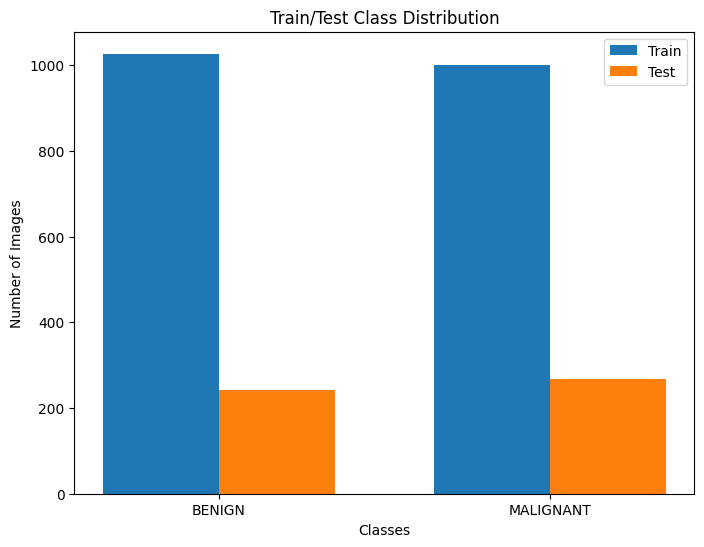

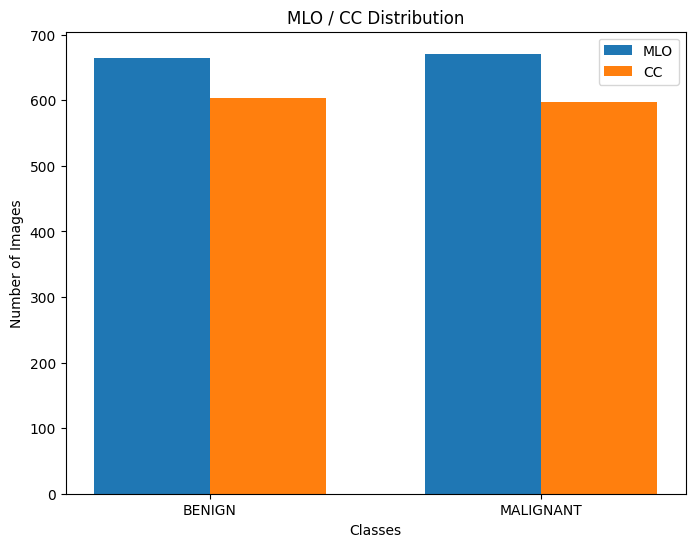

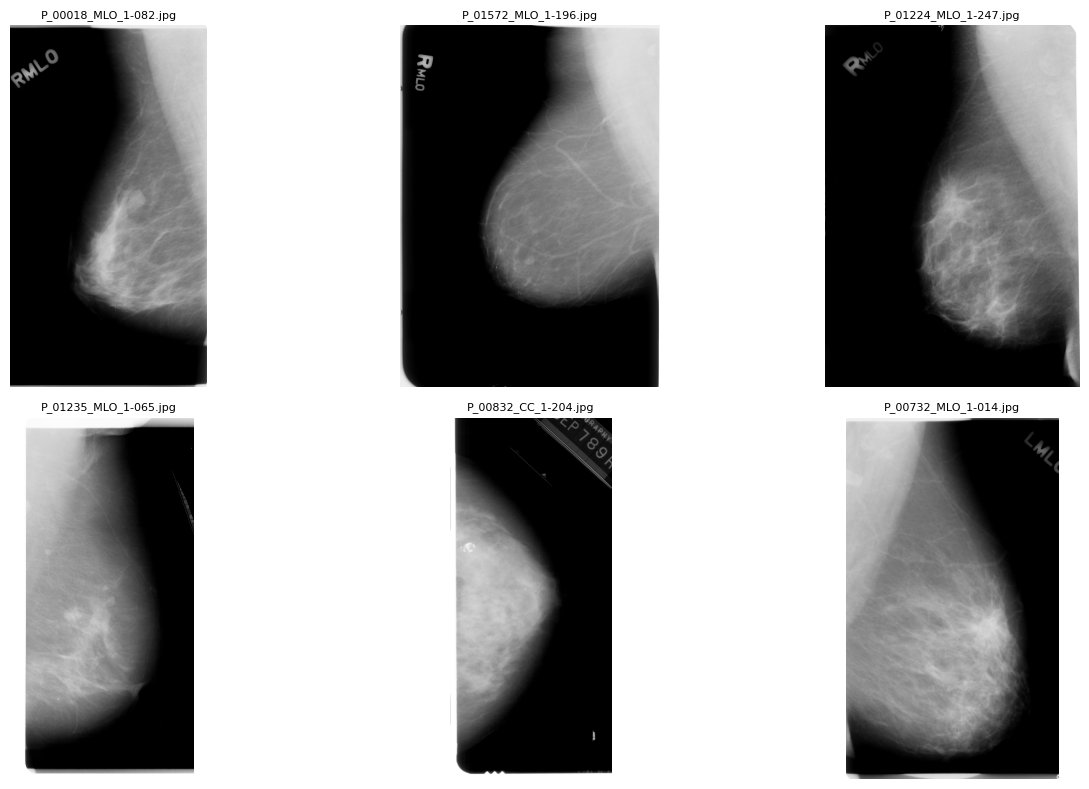

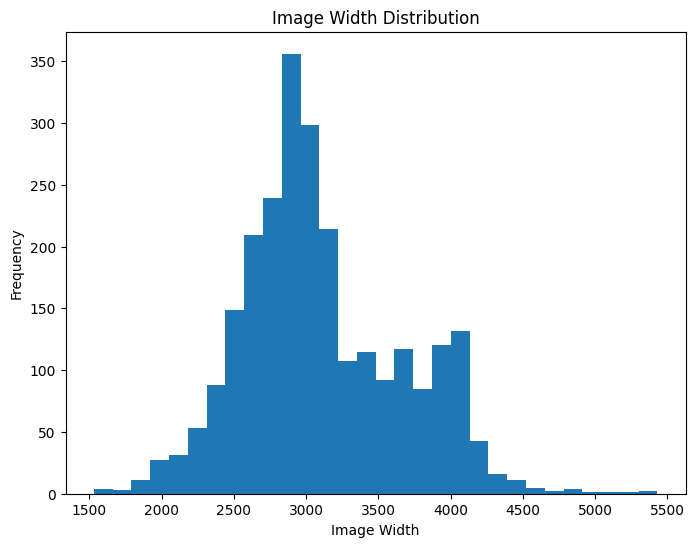

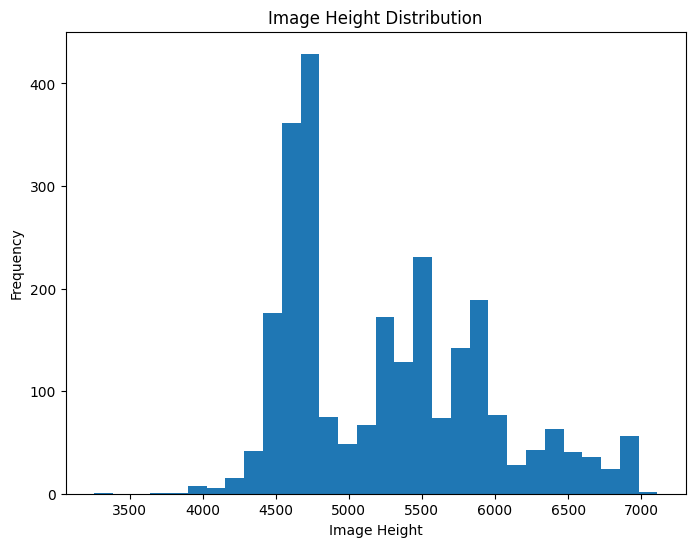


DATASET QUALITY CHECK

Corrupted Images : 0
No corrupted images found.

ANALYSIS COMPLETED.


In [31]:
# =========================================================
# CBIS_2CLASS_MLO_CC DATASET ANALYSIS
# =========================================================

import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# =========================================================
# DATASET PATH
# =========================================================

DATASET_DIR = "/content/CBIS_2CLASS_MLO_CC"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

CLASSES = ["BENIGN", "MALIGNANT"]

# =========================================================
# DATASET SUMMARY
# =========================================================

summary = []

for split_name, split_dir in [("TRAIN", TRAIN_DIR),
                              ("TEST", TEST_DIR)]:

    for cls in CLASSES:

        class_dir = os.path.join(split_dir, cls)

        images = glob(os.path.join(class_dir, "*.jpg"))

        total = len(images)

        mlo = 0
        cc  = 0

        widths  = []
        heights = []

        for img_path in images:

            fname = os.path.basename(img_path).upper()

            # View analizi
            if "_MLO_" in fname:
                mlo += 1

            elif "_CC_" in fname:
                cc += 1

            # Görüntü boyutu
            try:
                img = Image.open(img_path)
                w, h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

        summary.append({
            "Split"           : split_name,
            "Class"           : cls,
            "Total Images"    : total,
            "MLO Images"      : mlo,
            "CC Images"       : cc,
            "Avg Width"       : round(np.mean(widths), 2),
            "Avg Height"      : round(np.mean(heights), 2),
            "Min Width"       : np.min(widths),
            "Max Width"       : np.max(widths),
            "Min Height"      : np.min(heights),
            "Max Height"      : np.max(heights)
        })

summary_df = pd.DataFrame(summary)

# =========================================================
# GENEL BİLGİLER
# =========================================================

total_images = summary_df["Total Images"].sum()
total_mlo    = summary_df["MLO Images"].sum()
total_cc     = summary_df["CC Images"].sum()

general_info = pd.DataFrame([{
    "Dataset Name" : "CBIS_2CLASS_MLO_CC",
    "Classes"      : "BENIGN / MALIGNANT",
    "Total Images" : total_images,
    "Total MLO"    : total_mlo,
    "Total CC"     : total_cc,
    "Train Ratio"  : "80%",
    "Test Ratio"   : "20%"
}])

# =========================================================
# PRINT RESULTS
# =========================================================

print("=" * 70)
print("CBIS_2CLASS_MLO_CC DATASET ANALYSIS")
print("=" * 70)

print("\nGENERAL INFO\n")
print(general_info.to_string(index=False))

print("\nDETAILED ANALYSIS\n")
print(summary_df.to_string(index=False))

# =========================================================
# CLASS DISTRIBUTION GRAPH
# =========================================================

train_counts = []
test_counts  = []

for cls in CLASSES:

    train_imgs = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    test_imgs  = glob(os.path.join(TEST_DIR, cls, "*.jpg"))

    train_counts.append(len(train_imgs))
    test_counts.append(len(test_imgs))

x = np.arange(len(CLASSES))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, train_counts, width, label='Train')
plt.bar(x + width/2, test_counts, width, label='Test')

plt.xticks(x, CLASSES)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Train/Test Class Distribution")

plt.legend()

plt.show()

# =========================================================
# MLO / CC DISTRIBUTION
# =========================================================

mlo_counts = []
cc_counts  = []

for cls in CLASSES:

    imgs = glob(os.path.join(TRAIN_DIR, cls, "*.jpg")) + \
           glob(os.path.join(TEST_DIR, cls, "*.jpg"))

    mlo = 0
    cc  = 0

    for img in imgs:

        fname = os.path.basename(img).upper()

        if "_MLO_" in fname:
            mlo += 1

        elif "_CC_" in fname:
            cc += 1

    mlo_counts.append(mlo)
    cc_counts.append(cc)

x = np.arange(len(CLASSES))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, mlo_counts, width, label='MLO')
plt.bar(x + width/2, cc_counts, width, label='CC')

plt.xticks(x, CLASSES)

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("MLO / CC Distribution")

plt.legend()

plt.show()

# =========================================================
# RANDOM IMAGE VISUALIZATION
# =========================================================

plt.figure(figsize=(14,8))

sample_images = []

for cls in CLASSES:

    imgs = glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))

    sample_images.extend(imgs[:3])

for i, img_path in enumerate(sample_images):

    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)

    plt.imshow(img, cmap='gray')

    plt.title(os.path.basename(img_path), fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# IMAGE SIZE DISTRIBUTION
# =========================================================

all_widths  = []
all_heights = []

for split in ["train", "test"]:

    for cls in CLASSES:

        images = glob(
            os.path.join(DATASET_DIR, split, cls, "*.jpg")
        )

        for img_path in images:

            try:
                img = Image.open(img_path)

                w, h = img.size

                all_widths.append(w)
                all_heights.append(h)

            except:
                pass

plt.figure(figsize=(8,6))

plt.hist(all_widths, bins=30)

plt.xlabel("Image Width")
plt.ylabel("Frequency")
plt.title("Image Width Distribution")

plt.show()

plt.figure(figsize=(8,6))

plt.hist(all_heights, bins=30)

plt.xlabel("Image Height")
plt.ylabel("Frequency")
plt.title("Image Height Distribution")

plt.show()

# =========================================================
# DATASET QUALITY CHECK
# =========================================================

corrupted = []

for split in ["train", "test"]:

    for cls in CLASSES:

        images = glob(
            os.path.join(DATASET_DIR, split, cls, "*.jpg")
        )

        for img_path in images:

            try:
                img = Image.open(img_path)
                img.verify()

            except:
                corrupted.append(img_path)

print("\n" + "=" * 70)
print("DATASET QUALITY CHECK")
print("=" * 70)

print(f"\nCorrupted Images : {len(corrupted)}")

if len(corrupted) > 0:

    print("\nCorrupted File List:")

    for c in corrupted[:20]:
        print(c)

else:
    print("No corrupted images found.")

print("\nANALYSIS COMPLETED.")